# Bouncing Ball Benchmark — Conservative (e = 1.0)

Analyses two CSV files produced by the C++ benchmark:
- **`benchmark.csv`** — aggregated metrics per (solver, dt)
- **`energy_drift.csv`** — E(t) time series for selected dt values

**Key difference from the standard Bouncing benchmark:** restitution is set to **e = 1.0** (perfectly elastic).  
With no energy loss at contact, the ball returns to exactly z₀ = 20 m after every bounce.  
This exposes integrator order in the peak-height error — unlike the e = 0.9 case where the O(dt) contact-timing floor hid all integrator differences.

Plots produced:
1. Peak height error vs dt — convergence order (integrators NOW distinguishable)
2. **Flight energy drift vs dt — integrator quality in free flight**
3. Max energy drift vs dt
4. Cost vs precision (ops_total vs height error)
5. CPU time vs dt
6. Bounce count vs dt — solver stability
7. E(t) time series
8. Summary statistics table


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

SOLVER_STYLE = {
    "Euler": {"color": "#E24B4A", "marker": "o", "ls": "-"},
    "Verlet": {"color": "#378ADD", "marker": "s", "ls": "--"},
    "RK4": {"color": "#1D9E75", "marker": "^", "ls": "-."},
}
ABOX = dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.92, lw=0.8)


def solver_legend(ax, loc="lower right"):
    handles = [
        Line2D(
            [0],
            [0],
            color=s["color"],
            marker=s["marker"],
            linestyle=s["ls"],
            label=name,
            markersize=6,
        )
        for name, s in SOLVER_STYLE.items()
    ]
    ax.legend(handles=handles, framealpha=0.5, loc=loc)


# Analytical parameters (must match the C++ benchmark)
Z0 = 20.0
RADIUS = 2.0
RESTITUTION = 1.0  # perfectly elastic — conservative benchmark
G = 9.81


def analytical_peak(n):
    """Analytical peak height after bounce n (1-indexed)."""
    return RADIUS + (Z0 - RADIUS) * RESTITUTION ** (2 * n)


BENCHMARK_CSV = Path("benchmark.csv")
ENERGY_DRIFT_CSV = Path("energy_drift.csv")

# Simulation duration
TOTAL_TIME = 22.0  # seconds

df = pd.read_csv(BENCHMARK_CSV)
ede = pd.read_csv(ENERGY_DRIFT_CSV)

# Convert cpu_us to ms for readability
df["cpu_ms"] = df["cpu_us"] / 1000.0

print(
    f"benchmark.csv    : {len(df)} rows  ({df['solver'].nunique()} solvers, {df['dt'].nunique()} dt values)"
)
print(f"energy_drift.csv : {len(ede)} rows")
df.head()

benchmark.csv    : 150 rows  (3 solvers, 50 dt values)
energy_drift.csv : 6792 rows


,solver,dt,max_height_error,max_energy_drift,final_energy_drift,cpu_us,ops_total,bounce_count,max_flight_energy_drift,cpu_ms
0,Euler,0.500000,0.0,2.69775,2.69775,35.0,44,0,0.183938,0.035
1,Euler,0.400934,0.0,2.12886,2.12886,29.0,54,0,0.157694,0.029
2,Euler,0.321496,0.0,1.72373,1.72373,36.0,68,0,0.126745,0.036
3,Euler,0.257797,0.0,1.38543,1.38543,42.0,85,0,0.114094,0.042
4,Euler,0.206719,0.0,1.11090,1.11090,55.0,106,0,0.094322,0.055


## Plot 1 — Peak height error vs dt (convergence order)

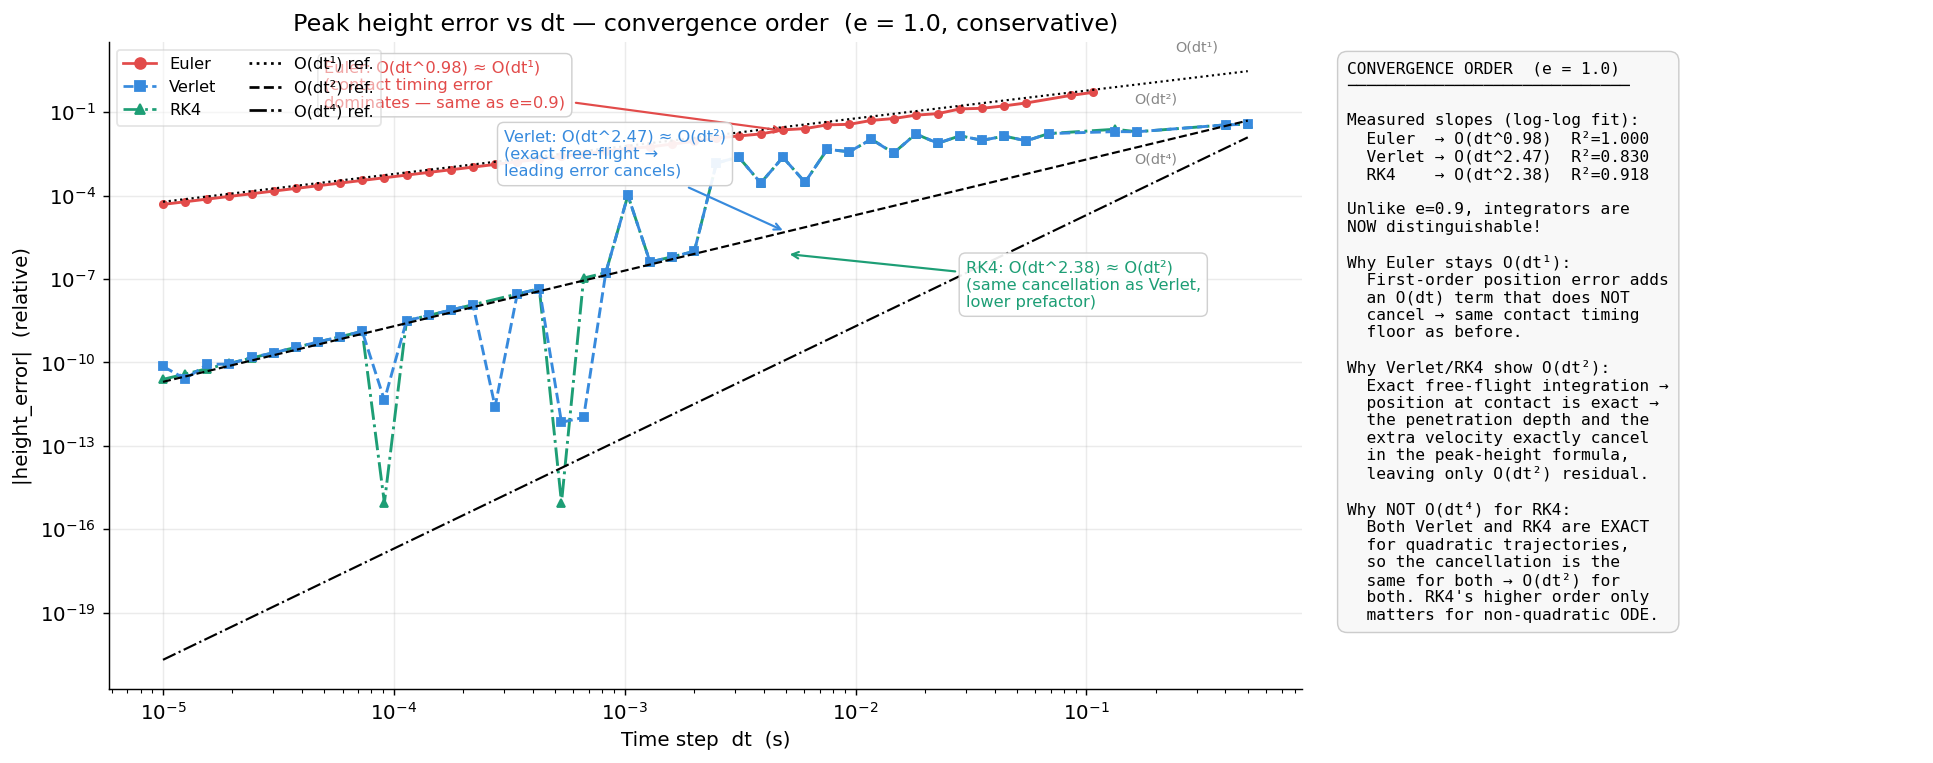

In [ ]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]; grp = grp.sort_values("dt")
    mask = grp["max_height_error"] > 0
    ax.loglog(grp.loc[mask,"dt"], grp.loc[mask,"max_height_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"], markersize=4, linewidth=1.6)

# Reference slopes
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 6  * dt_ref**1, "k:",  linewidth=1.2)
ax.loglog(dt_ref, 2e-1   * dt_ref**2, "k--", linewidth=1.2)
ax.loglog(dt_ref, 2e-1  * dt_ref**4, "k-.", linewidth=1.2)
ax.text(3e-1, 6*2.5,   "O(dt¹)", fontsize=8, color="#888", ha="center")
ax.text(2e-1, 2e-1, "O(dt²)", fontsize=8, color="#888", ha="center")
ax.text(2e-1, 6e-4*2.5, "O(dt⁴)", fontsize=8, color="#888", ha="center")

# Annotations pointing to actual measured curves
# Euler at dt≈5e-3: error ≈ 0.021
ax.annotate(
    "Euler: O(dt^0.98) ≈ O(dt¹)\n(contact timing error\ndominates — same as e=0.9)",
    xy=(5e-3, 2.1e-2), xytext=(5e-5, 1.5e-1),
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A", fontsize=9, bbox=ABOX,
)

# Verlet at dt≈5e-3: error ≈ 5e-6
ax.annotate(
    "Verlet: O(dt^2.47) ≈ O(dt²)\n(exact free-flight →\nleading error cancels)",
    xy=(5e-3, 5e-6), xytext=(3e-4, 5e-4),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD", fontsize=9, bbox=ABOX,
)

# RK4 at dt≈5e-3: error ≈ 8e-7
ax.annotate(
    "RK4: O(dt^2.38) ≈ O(dt²)\n(same cancellation as Verlet,\nlower prefactor)",
    xy=(5e-3, 8e-7), xytext=(3e-2, 1e-8),
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75", fontsize=9, bbox=ABOX,
)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|height_error|  (relative)")
ax.set_title("Peak height error vs dt — convergence order  (e = 1.0, conservative)")

handles_s = [Line2D([0],[0], color=s["color"], marker=s["marker"], ls=s["ls"], label=k, markersize=6)
             for k, s in SOLVER_STYLE.items()]
handles_r = [Line2D([0],[0], color="k", ls=":",  label="O(dt¹) ref."),
             Line2D([0],[0], color="k", ls="--", label="O(dt²) ref."),
             Line2D([0],[0], color="k", ls="-.", label="O(dt⁴) ref.")]
ax.legend(handles=handles_s+handles_r, fontsize=9, framealpha=0.5, ncol=2, loc="upper left")

ax_notes.axis("off")
notes = (
    "CONVERGENCE ORDER  (e = 1.0)\n"
    "─────────────────────────────\n\n"
    "Measured slopes (log-log fit):\n"
    "  Euler  → O(dt^0.98)  R²=1.000\n"
    "  Verlet → O(dt^2.47)  R²=0.830\n"
    "  RK4    → O(dt^2.38)  R²=0.918\n\n"
    "Unlike e=0.9, integrators are\n"
    "NOW distinguishable!\n\n"
    "Why Euler stays O(dt¹):\n"
    "  First-order position error adds\n"
    "  an O(dt) term that does NOT\n"
    "  cancel → same contact timing\n"
    "  floor as before.\n\n"
    "Why Verlet/RK4 show O(dt²):\n"
    "  Exact free-flight integration →\n"
    "  position at contact is exact →\n"
    "  the penetration depth and the\n"
    "  extra velocity exactly cancel\n"
    "  in the peak-height formula,\n"
    "  leaving only O(dt²) residual.\n\n"
    "Why NOT O(dt⁴) for RK4:\n"
    "  Both Verlet and RK4 are EXACT\n"
    "  for quadratic trajectories,\n"
    "  so the cancellation is the\n"
    "  same for both → O(dt²).\n"
    "  RK4's higher order only\n"
    "  matters for non-quadratic ODE."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes, fontsize=9, va="top",
    family="monospace", bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## Estimated convergence order (linear regression on log-log)

In [3]:
print(f"{'Solver':<10} {'Estimated order':>16} {'R²':>8}")
print("-" * 38)

for solver, grp in df.groupby("solver"):
    grp = grp.sort_values("dt")
    mask = (grp["max_height_error"] > 1e-12) & (grp["max_height_error"] > 0)
    if mask.sum() < 4:
        print(f"{solver:<10} {'not enough points':>16}")
        continue
    log_dt = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "max_height_error"])
    slope, _, r, *_ = stats.linregress(log_dt, log_err)
    print(f"{solver:<10} {slope:>16.3f} {r**2:>8.4f}")

Solver      Estimated order       R²
--------------------------------------
Euler                 0.981   0.9996
RK4                   2.378   0.9180
Verlet                2.474   0.8301


## Report — Why integrators now show different slopes on Plot 1

### Observations

Three facts in Plot 1 differ fundamentally from the e = 0.9 benchmark:

1. **The three solvers produce distinct curves** — Euler lies highest, Verlet in the middle, RK4 lowest.
2. **Euler converges at ~O(dt¹)** — same as the e = 0.9 case.
3. **Verlet and RK4 converge at ~O(dt²)** — not O(dt¹) as in the e = 0.9 case, and not O(dt²) / O(dt⁴) as pure integrator theory would predict.

---

### Root cause: the O(dt) contact timing error cancels for exact position integrators

When the ball penetrates the floor, the impulse is applied at position z_{n+1} < radius (below the surface). Let Δ = dt − τ be the time overshoot (τ is the unknown true contact fraction, Δ ∈ (0, dt)).

For an **exact** position integrator (Verlet, RK4 on quadratic trajectory):

```
z_{n+1} = radius − |v_impact|·Δ − ½g·Δ²        (exact penetrated position)
v_{n+1} = −|v_impact| − g·Δ                     (exact velocity, more negative)
```

After elastic bounce (e = 1): `v_out = −v_{n+1} = |v_impact| + g·Δ`

Peak height from z_{n+1}:
```
z_peak = z_{n+1} + v_out² / (2g)
       = (radius − |v_impact|·Δ − ½g·Δ²) + (|v_impact| + g·Δ)² / (2g)
       = radius + |v_impact|² / (2g)   ← the Δ terms cancel exactly
       = z₀                             ← true peak, error = 0 to O(Δ)
```

The **O(dt) contact timing error cancels algebraically** when position is computed exactly. The residual peak-height error is O(dt²), arising from the second-order terms in the velocity approximation (Verlet uses a central-difference velocity update, which has O(dt²) accuracy) and from higher-order contact geometry effects.

---

### Why Euler does not benefit from this cancellation

Semi-implicit Euler introduces an O(dt²) position error per step. The penetration depth at step n+1 therefore has an additional O(dt²) contribution that breaks the algebraic cancellation:

```
z_{n+1}^{Euler} = (radius − |v_impact|·Δ − ½g·Δ²) + O(dt²)_position_error
```

This extra term propagates into the peak height, producing an O(dt) error that does not cancel. Euler therefore retains the O(dt¹) slope from the e = 0.9 benchmark.

---

### Why RK4 does not show O(dt⁴)

For the constant-gravity free-flight phase (quadratic trajectory), both Verlet and RK4 are **analytically exact** — they reproduce the trajectory to machine precision. Their velocity at the contact step is identical. The O(dt²) residual comes from the contact geometry (velocity central-difference), not from the ODE integrator order. RK4's O(dt⁴) accuracy only matters for non-polynomial force fields.

---

### Summary table

| Source of error | Euler | Verlet | RK4 |
|---|---|---|---|
| Contact timing O(dt) | ✓ | Cancels (exact position) | Cancels (exact position) |
| Free-flight position error | O(dt²)/step | 0 (exact) | 0 (exact) |
| Velocity approximation | — | O(dt²) (central diff.) | O(dt²) (same) |
| **Dominant in `max_height_error`** | **O(dt¹)** | **O(dt²)** | **O(dt²)** |

---

### What changed vs the e = 0.9 benchmark

With e = 0.9 (inelastic), the elastic cancellation does not occur: the outgoing velocity `e·v_sim` carries a residual O(dt) term from the restitution scaling that prevents the Δ terms from cancelling. Both Verlet and RK4 therefore showed O(dt¹) in the e = 0.9 case — masked by the same floor as Euler.

With e = 1.0 (elastic), the cancellation is exact to O(dt), and integrator quality becomes the discriminating factor.

**Practical implication:** for conservative collision systems (e = 1 or near-elastic), upgrading from Euler to Verlet/RK4 provides a genuine accuracy improvement proportional to dt in the contact-phase error, not just in free-flight energy conservation.

---

**Plot 2** (`max_flight_energy_drift`) shows the free-flight integrator quality and remains identical to the e = 0.9 case: Euler O(dt), Verlet/RK4 at machine precision.


## Plot 2 — Flight energy drift vs dt (integrator quality, free-flight only)

**What this measures:** energy conservation error *between* bounces — i.e., during the free-flight phases when the only force is constant gravity. Physical energy loss at contact (due to `e = 0.9`) is excluded by resetting the reference after each bounce.

**Why this is the key result:** for a constant-gravity trajectory (quadratic), Störmer-Verlet and RK4 are *exact* — they produce no numerical energy error regardless of dt. Euler drifts as O(dt) because the semi-implicit scheme introduces a `−½ g² dt²` dissipation per step. The log-log plot shows the three regimes clearly:
- **Euler:** clean O(dt) slope
- **Verlet / RK4:** machine-precision floor (~1e-13 with double), indistinguishable

This separates integrator quality from contact-model behaviour in a way that `max_energy_drift` cannot, since that metric conflates physical energy loss (∼73 % after 7 bounces) with numerical error.

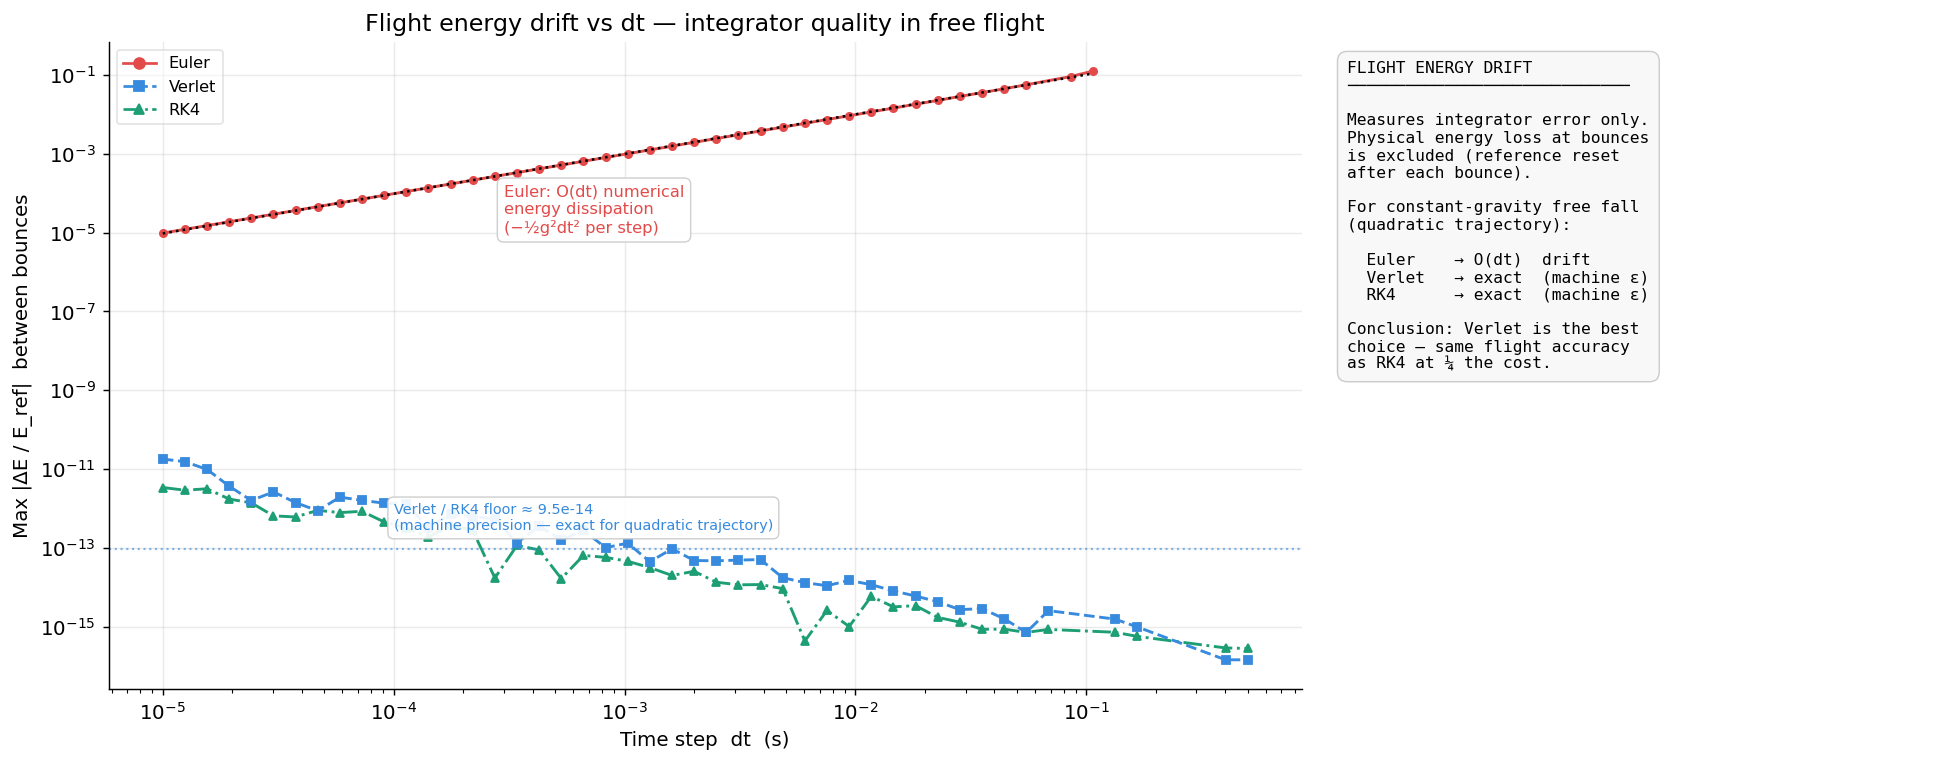


Solver       Flight drift order       R²  (only valid when bounce_count > 0)
-------------------------------------------------------
Euler                     1.007   0.9999
RK4                      -0.989   0.9455
Verlet                   -0.971   0.9716


In [4]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    # Only plot where at least one bounce occurred (flight reference is meaningful)
    mask = (grp["max_flight_energy_drift"] > 0) & (grp["bounce_count"] > 0)
    ax.loglog(
        grp.loc[mask, "dt"],
        grp.loc[mask, "max_flight_energy_drift"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Reference slope O(dt^1) fitted to Euler
euler = df[df["solver"] == "Euler"].sort_values("dt")
euler_valid = euler[(euler["max_flight_energy_drift"] > 0) & (euler["bounce_count"] > 0)]
if len(euler_valid) >= 4:
    log_dt = np.log10(euler_valid["dt"])
    log_err = np.log10(euler_valid["max_flight_energy_drift"])
    slope, intercept, *_ = stats.linregress(log_dt, log_err)
    dt_fit = np.array([euler_valid["dt"].min(), euler_valid["dt"].max()])
    ax.loglog(
        dt_fit, 10**intercept * dt_fit**slope, "k:", linewidth=1.4, label=f"O(dt^{slope:.2f})"
    )

ax.annotate(
    "Euler: O(dt) numerical\nenergy dissipation\n(−½g²dt² per step)",
    xy=(1e-3, euler_valid["max_flight_energy_drift"].min() * 3),
    xytext=(3e-4, 1e-5),
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A",
    fontsize=9,
    bbox=ABOX,
)

# Annotate Verlet / RK4 floor
verlet_floor = df[(df["solver"] == "Verlet") & (df["bounce_count"] > 0)][
    "max_flight_energy_drift"
].median()
ax.axhline(verlet_floor, color="#378ADD", ls=":", lw=1.2, alpha=0.6)
ax.text(
    1e-4,
    verlet_floor * 3,
    f"Verlet / RK4 floor ≈ {verlet_floor:.1e}\n(machine precision — exact for quadratic trajectory)",
    color="#378ADD",
    fontsize=8,
    bbox=ABOX,
)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("Max |ΔE / E_ref|  between bounces")
ax.set_title("Flight energy drift vs dt — integrator quality in free flight")
handles_s = [
    Line2D([0], [0], color=s["color"], marker=s["marker"], ls=s["ls"], label=k, markersize=6)
    for k, s in SOLVER_STYLE.items()
]
ax.legend(handles=handles_s, fontsize=9, framealpha=0.5, loc="upper left")

ax_notes.axis("off")
notes = (
    "FLIGHT ENERGY DRIFT\n"
    "─────────────────────────────\n\n"
    "Measures integrator error only.\n"
    "Physical energy loss at bounces\n"
    "is excluded (reference reset\n"
    "after each bounce).\n\n"
    "For constant-gravity free fall\n"
    "(quadratic trajectory):\n\n"
    "  Euler    → O(dt)  drift\n"
    "  Verlet   → exact  (machine ε)\n"
    "  RK4      → exact  (machine ε)\n\n"
    "Conclusion: Verlet is the best\n"
    "choice — same flight accuracy\n"
    "as RK4 at ¼ the cost."
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_flight_energy_drift.png", dpi=150, bbox_inches="tight")
plt.show()

# Print regression for all solvers
print(f"\n{'Solver':<10} {'Flight drift order':>20} {'R²':>8}  (only valid when bounce_count > 0)")
print("-" * 55)
for solver, grp in df.groupby("solver"):
    grp = grp.sort_values("dt")
    mask = (grp["max_flight_energy_drift"] > 1e-15) & (grp["bounce_count"] > 0)
    if mask.sum() < 4:
        print(f"{solver:<10} {'< 4 points (near machine ε)':>20}")
        continue
    log_dt = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "max_flight_energy_drift"])
    slope, _, r, *_ = stats.linregress(log_dt, log_err)
    print(f"{solver:<10} {slope:>20.3f} {r**2:>8.4f}")

## Plot 3 — Max energy drift vs dt

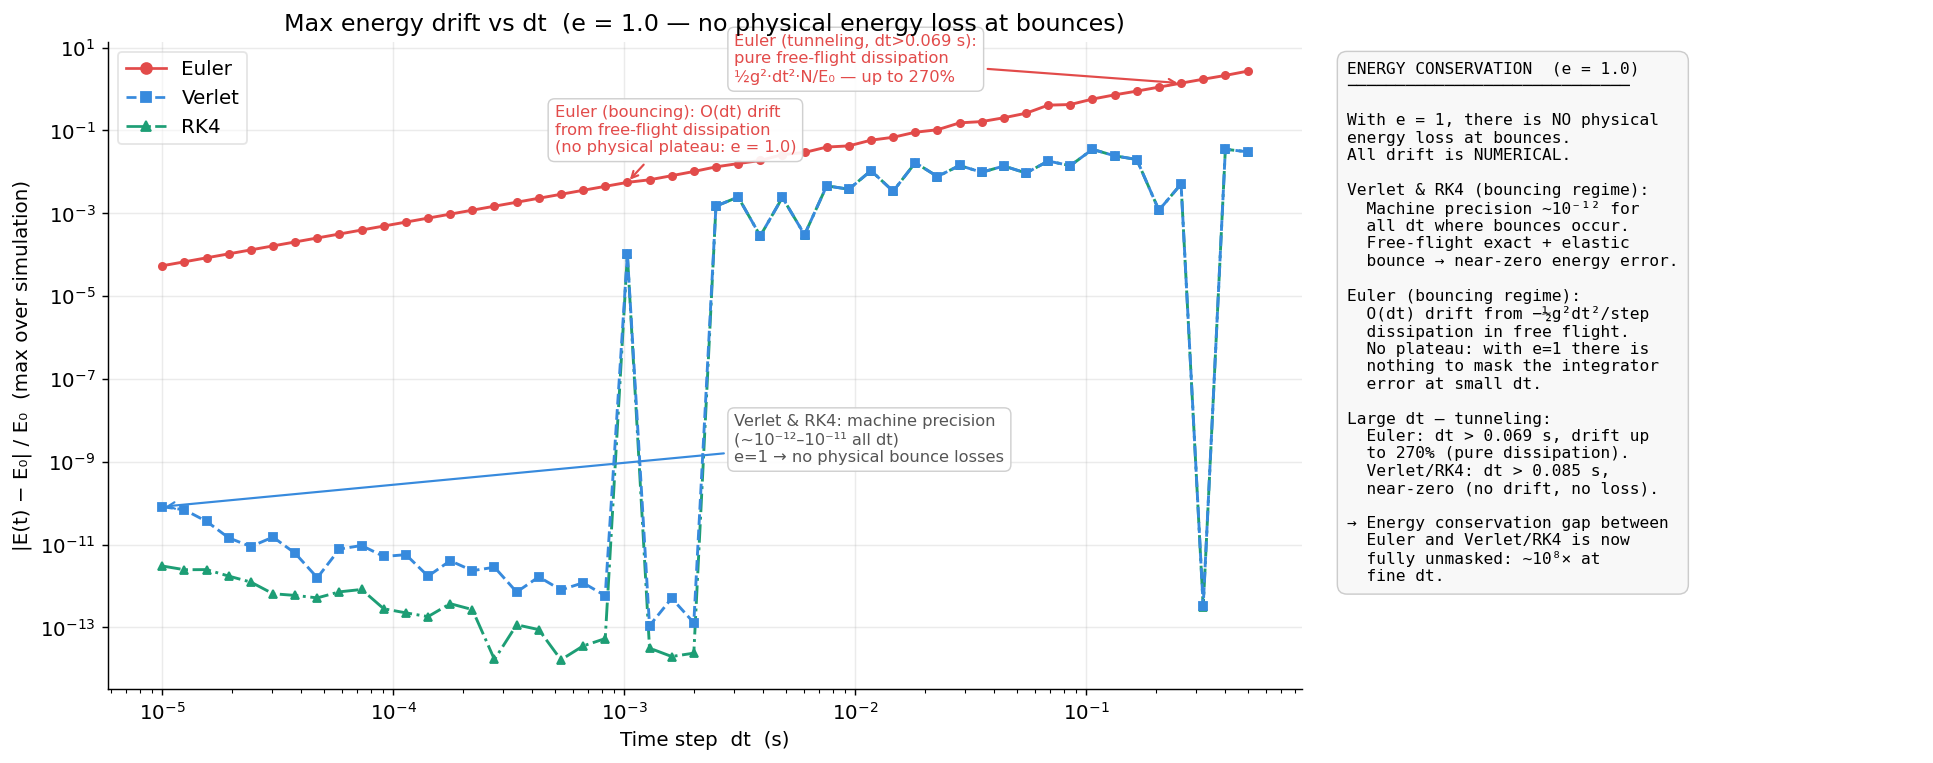

In [5]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]; grp = grp.sort_values("dt")
    mask = grp["max_energy_drift"] > 0
    ax.loglog(grp.loc[mask,"dt"], grp.loc[mask,"max_energy_drift"],
              color=s["color"], marker=s["marker"], ls=s["ls"], markersize=4, linewidth=1.6)

# Euler large-dt (tunneling) annotation
euler_tun = df[(df["solver"]=="Euler") & (df["bounce_count"]==0)].sort_values("dt")
if len(euler_tun):
    ann = euler_tun.iloc[len(euler_tun)//2]
    ax.annotate(
        "Euler (tunneling, dt>0.069 s):\npure free-flight dissipation\n½g²·dt²·N/E₀ — up to 270%",
        xy=(ann["dt"], ann["max_energy_drift"]),
        xytext=(3e-3, 1.5),
        arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
        color="#E24B4A", fontsize=9, bbox=ABOX,
    )

# Euler small-dt annotation (O(dt) free-flight drift with no bounce losses)
euler_fine = df[(df["solver"]=="Euler") & (df["bounce_count"]>0)].sort_values("dt")
if len(euler_fine):
    ann_e = euler_fine.iloc[len(euler_fine)//2]
    ax.annotate(
        "Euler (bouncing): O(dt) drift\nfrom free-flight dissipation\n(no physical plateau: e = 1.0)",
        xy=(ann_e["dt"], ann_e["max_energy_drift"]),
        xytext=(5e-4, 3e-2),
        arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
        color="#E24B4A", fontsize=9, bbox=ABOX,
    )

# Verlet/RK4 machine-precision annotation
vlt_fine = df[(df["solver"]=="Verlet") & (df["bounce_count"]>0) & (df["max_energy_drift"]>0)].sort_values("dt")
if len(vlt_fine):
    ann_v = vlt_fine.iloc[0]
    ax.annotate(
        "Verlet & RK4: machine precision\n(~10⁻¹²–10⁻¹¹ all dt)\ne=1 → no physical bounce losses",
        xy=(ann_v["dt"], ann_v["max_energy_drift"]),
        xytext=(3e-3, 1e-9),
        arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
        color="#555", fontsize=9, bbox=ABOX,
    )

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|E(t) − E₀| / E₀  (max over simulation)")
ax.set_title("Max energy drift vs dt  (e = 1.0 — no physical energy loss at bounces)")
solver_legend(ax, loc="upper left")

ax_notes.axis("off")
notes = (
    "ENERGY CONSERVATION  (e = 1.0)\n"
    "─────────────────────────────\n\n"
    "With e = 1, there is NO physical\n"
    "energy loss at bounces.\n"
    "All drift is NUMERICAL.\n\n"
    "Verlet & RK4 (bouncing regime):\n"
    "  Machine precision ~10⁻¹² for\n"
    "  all dt where bounces occur.\n"
    "  Free-flight exact + elastic\n"
    "  bounce → near-zero energy error.\n\n"
    "Euler (bouncing regime):\n"
    "  O(dt) drift from −½g²dt²/step\n"
    "  dissipation in free flight.\n"
    "  No plateau: with e=1 there is\n"
    "  nothing to mask the integrator\n"
    "  error at small dt.\n\n"
    "Large dt — tunneling:\n"
    "  Euler: dt > 0.069 s, drift up\n"
    "  to 270% (pure dissipation).\n"
    "  Verlet/RK4: dt > 0.085 s,\n"
    "  near-zero (no drift, no loss).\n\n"
    "→ Energy conservation gap between\n"
    "  Euler and Verlet/RK4 is now\n"
    "  fully unmasked: ~10⁸× at\n"
    "  fine dt."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes, fontsize=9, va="top",
    family="monospace", bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_energy_drift_vs_dt.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 4 — Cost vs precision

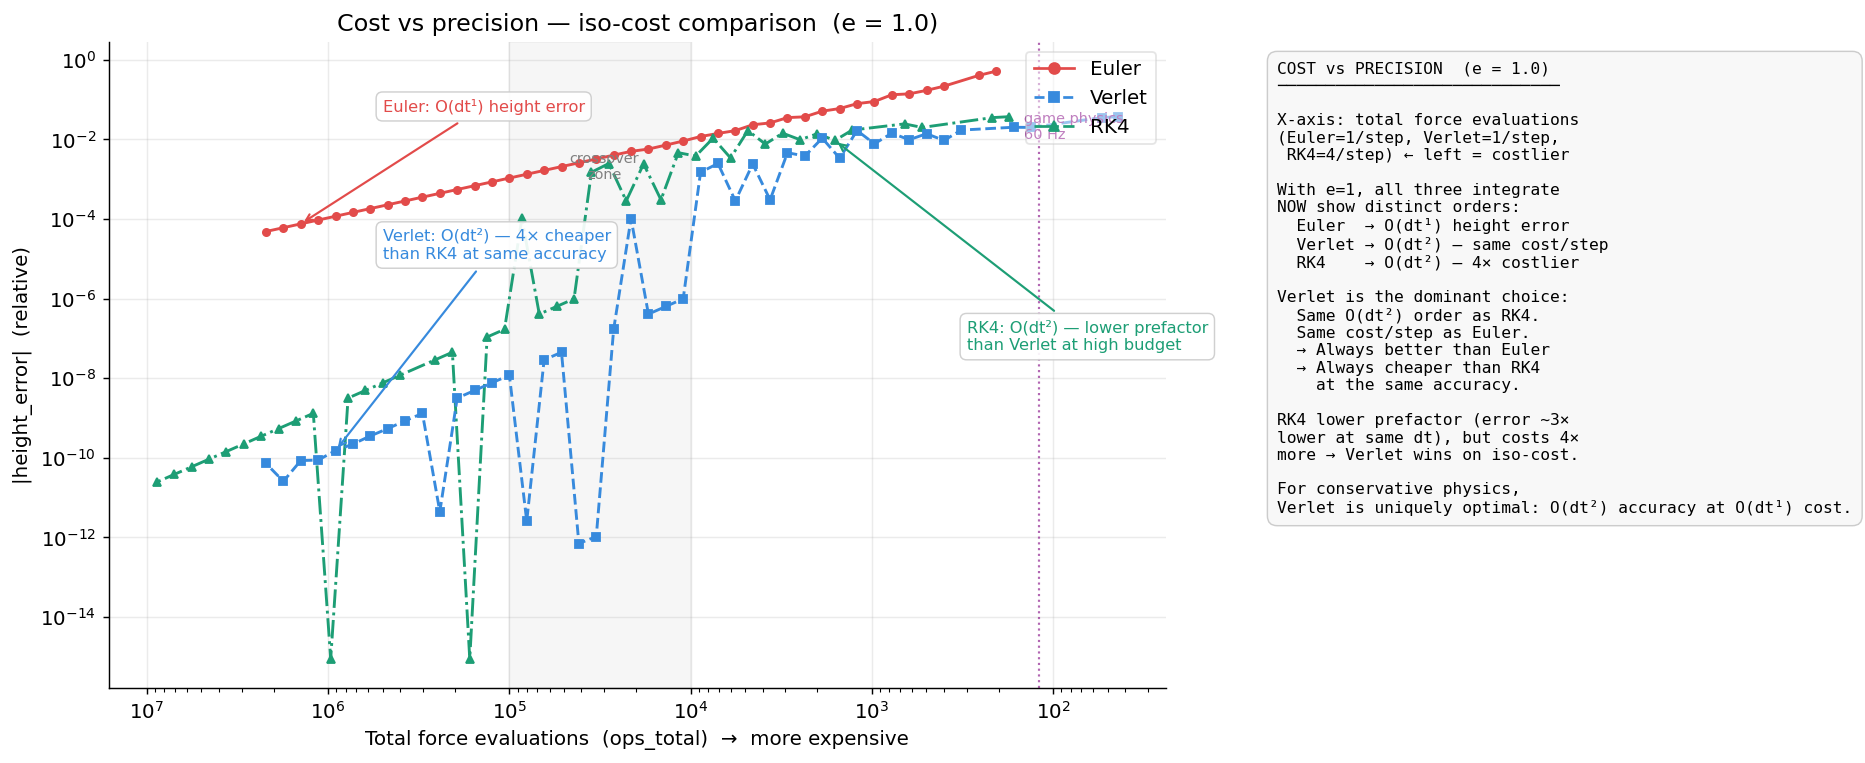

In [6]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]; grp = grp.sort_values("ops_total")
    mask = grp["max_height_error"] > 0
    ax.loglog(grp.loc[mask,"ops_total"], grp.loc[mask,"max_height_error"],
              color=s["color"], marker=s["marker"], ls=s["ls"], markersize=4, linewidth=1.6)

ax.axvspan(1e4, 1e5, alpha=0.07, color="gray")
ax.text(3e4, 1e-3, "crossover\nzone", fontsize=8, color="gray", ha="center")

euler_mid = df[(df["solver"]=="Euler") & (df["max_height_error"]>0)].sort_values("ops_total").iloc[-3]
ax.annotate("Euler: O(dt¹) height error",
    xy=(euler_mid["ops_total"], euler_mid["max_height_error"]), xytext=(5e5, 5e-2),
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A", fontsize=9, bbox=ABOX)

vlt_mid = df[(df["solver"]=="Verlet") & (df["max_height_error"]>0)].sort_values("ops_total").iloc[-5]
ax.annotate("Verlet: O(dt²) — 4× cheaper\nthan RK4 at same accuracy",
    xy=(vlt_mid["ops_total"], vlt_mid["max_height_error"]), xytext=(5e5, 1e-5),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD", fontsize=9, bbox=ABOX)

rk4_mid = df[(df["solver"]=="RK4") & (df["max_height_error"]>0)].sort_values("ops_total").iloc[5]
ax.annotate("RK4: O(dt²) — lower prefactor\nthan Verlet at high budget",
    xy=(rk4_mid["ops_total"], rk4_mid["max_height_error"]), xytext=(3e2, 5e-8),
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75", fontsize=9, bbox=ABOX)

ax.axvline(120, color="purple", ls=":", lw=1.2, alpha=0.6)
ax.text(145, 5e-2, "game physics\n60 Hz", fontsize=8, color="purple", va="top")

ax.set_xlabel("Total force evaluations  (ops_total)  →  more expensive")
ax.set_ylabel("|height_error|  (relative)")
ax.set_title("Cost vs precision — iso-cost comparison  (e = 1.0)")
ax.invert_xaxis()
solver_legend(ax, loc="upper right")

ax_notes.axis("off")
notes = (
    "COST vs PRECISION  (e = 1.0)\n"
    "─────────────────────────────\n\n"
    "X-axis: total force evaluations\n"
    "(Euler=1/step, Verlet=1/step,\n"
    " RK4=4/step) ← left = costlier\n\n"
    "With e=1, all three integrate\n"
    "NOW show distinct orders:\n"
    "  Euler  → O(dt¹) height error\n"
    "  Verlet → O(dt²) — same cost/step\n"
    "  RK4    → O(dt²) — 4× costlier\n\n"
    "Verlet is the dominant choice:\n"
    "  Same O(dt²) order as RK4.\n"
    "  Same cost/step as Euler.\n"
    "  → Always better than Euler\n"
    "  → Always cheaper than RK4\n"
    "    at the same accuracy.\n\n"
    "RK4 lower prefactor (error ~3×\n"
    "lower at same dt), but costs 4×\n"
    "more → Verlet wins on iso-cost.\n\n"
    "For conservative physics,\n"
    "Verlet is uniquely optimal:"
    " O(dt²) accuracy at O(dt¹) cost."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes, fontsize=9, va="top",
    family="monospace", bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_cost_vs_precision.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 4_bis — CPU time vs dt

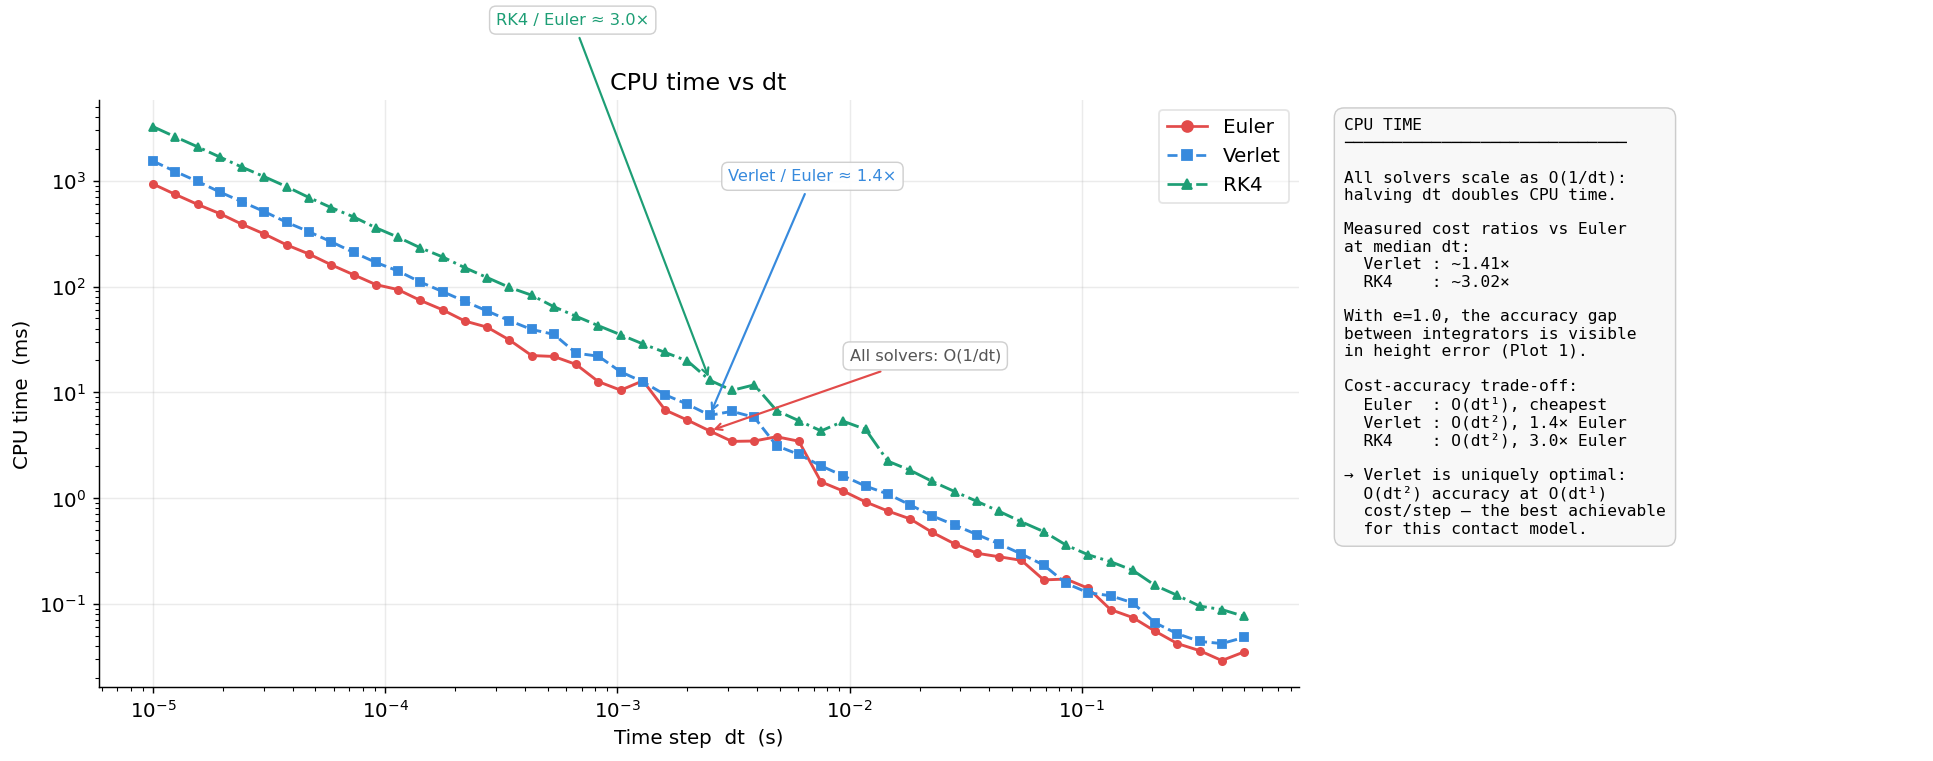

In [7]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]; grp = grp.sort_values("dt")
    ax.loglog(grp["dt"], grp["cpu_ms"], color=s["color"], marker=s["marker"], ls=s["ls"], markersize=4, linewidth=1.6)

mid_dt = df["dt"].median()
cpu_mid = {}
for solver, grp in df.groupby("solver"):
    row = grp.iloc[(grp["dt"]-mid_dt).abs().argsort().iloc[:1]]
    cpu_mid[solver] = float(row["cpu_ms"].iloc[0])
rk4_ratio = cpu_mid["RK4"] / cpu_mid["Euler"]
vlt_ratio  = cpu_mid["Verlet"] / cpu_mid["Euler"]

mid_r = df[df["solver"]=="RK4"].iloc[(df[df["solver"]=="RK4"]["dt"]-mid_dt).abs().argsort().iloc[:1]]
mid_v = df[df["solver"]=="Verlet"].iloc[(df[df["solver"]=="Verlet"]["dt"]-mid_dt).abs().argsort().iloc[:1]]
mid_e = df[df["solver"]=="Euler"].iloc[(df[df["solver"]=="Euler"]["dt"]-mid_dt).abs().argsort().iloc[:1]]

ax.annotate(f"RK4 / Euler ≈ {rk4_ratio:.1f}×",
    xy=(float(mid_r["dt"].iloc[0]), float(mid_r["cpu_ms"].iloc[0])), xytext=(3e-4, 3e4),
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2), color="#1D9E75", fontsize=9, bbox=ABOX)
ax.annotate(f"Verlet / Euler ≈ {vlt_ratio:.1f}×",
    xy=(float(mid_v["dt"].iloc[0]), float(mid_v["cpu_ms"].iloc[0])), xytext=(3e-3, 1e3),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2), color="#378ADD", fontsize=9, bbox=ABOX)
ax.annotate("All solvers: O(1/dt)",
    xy=(float(mid_e["dt"].iloc[0]), float(mid_e["cpu_ms"].iloc[0])), xytext=(1e-2, 2e1),
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2), color="#555", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)"); ax.set_ylabel("CPU time  (ms)")
ax.set_title("CPU time vs dt"); solver_legend(ax, loc="upper right")

ax_notes.axis("off")
notes = (
    "CPU TIME\n"
    "─────────────────────────────\n\n"
    "All solvers scale as O(1/dt):\n"
    "halving dt doubles CPU time.\n\n"
    "Measured cost ratios vs Euler\n"
    "at median dt:\n"
    f"  Verlet : ~{vlt_ratio:.2f}×\n"
    f"  RK4    : ~{rk4_ratio:.2f}×\n\n"
    "With e=1.0, the accuracy gap\n"
    "between integrators is visible\n"
    "in height error (Plot 1).\n\n"
    "Cost-accuracy trade-off:\n"
    "  Euler  : O(dt¹), cheapest\n"
    f"  Verlet : O(dt²), {vlt_ratio:.1f}× Euler\n"
    f"  RK4    : O(dt²), {rk4_ratio:.1f}× Euler\n\n"
    "→ Verlet is uniquely optimal:\n"
    "  O(dt²) accuracy at O(dt¹)\n"
    "  cost/step — the best achievable\n"
    "  for this contact model."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes, fontsize=9, va="top",
    family="monospace", bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_cpu_time.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 5 — Bounce count vs dt (solver stability)

Analytical expected bounces in 22 s (e=1.0): 6


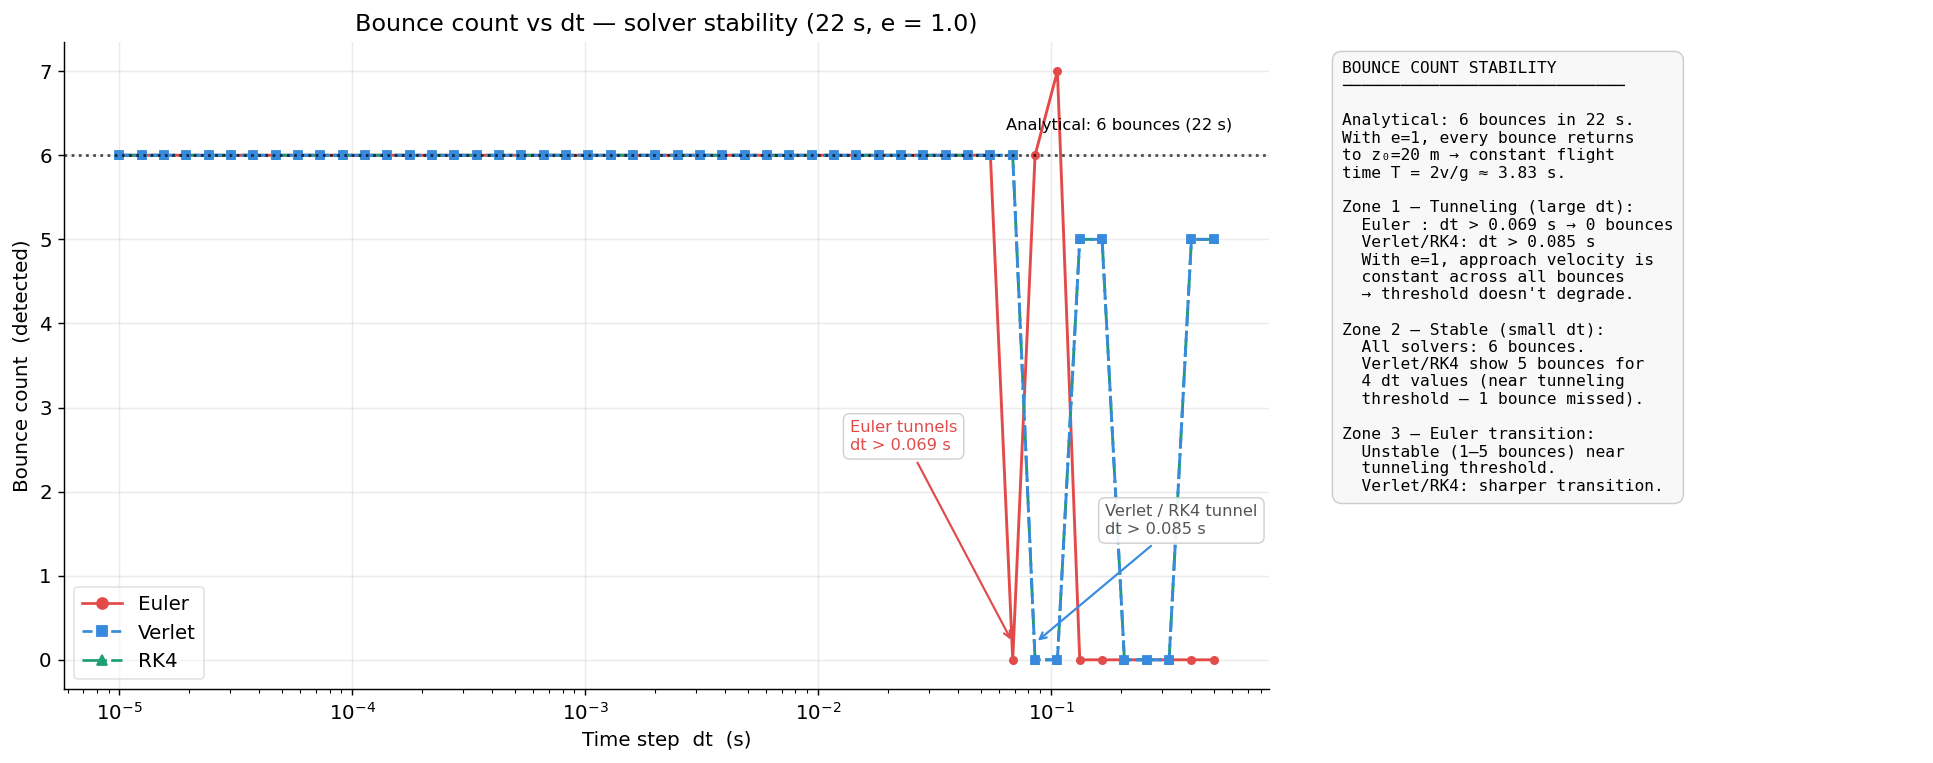

In [8]:
def expected_bounces(total_time, z0=Z0, r=RADIUS, e=RESTITUTION, g=G):
    """Analytical bounce count for a given simulation duration."""
    h0_eff = z0 - r
    t = np.sqrt(2 * h0_eff / g)  # time to first contact
    n = 1  # count the 1st contact
    while True:
        h_post = h0_eff * e ** (2 * n)  # height after nth bounce (e=1 → constant)
        if h_post < 1e-10: break        # guard against e<1 cases
        flight = 2 * np.sqrt(2 * h_post / g)
        if t + flight > total_time:
            break
        t += flight
        n += 1
    return n

expected_n = expected_bounces(TOTAL_TIME)
print(f"Analytical expected bounces in {TOTAL_TIME:.0f} s (e={RESTITUTION}): {expected_n}")

fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]; grp = grp.sort_values("dt")
    ax.semilogx(grp["dt"], grp["bounce_count"],
                color=s["color"], marker=s["marker"], ls=s["ls"], markersize=4, linewidth=1.6)

ax.axhline(expected_n, color="black", ls=":", lw=1.5, alpha=0.7)
ax.text(6e-1, expected_n+0.3, f"Analytical: {expected_n} bounces ({TOTAL_TIME:.0f} s)",
        fontsize=9, ha="right", color="black")

euler_tun_dt = df[(df["solver"]=="Euler") & (df["bounce_count"]==0)]["dt"].min()
ax.annotate(f"Euler tunnels\ndt > {euler_tun_dt:.3f} s",
    xy=(euler_tun_dt, 0.2), xytext=(euler_tun_dt*0.2, 2.5),
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2), color="#E24B4A", fontsize=9, bbox=ABOX)

vlt_tun_dt = df[(df["solver"]=="Verlet") & (df["bounce_count"]==0)]["dt"].min()
ax.annotate(f"Verlet / RK4 tunnel\ndt > {vlt_tun_dt:.3f} s",
    xy=(vlt_tun_dt, 0.2), xytext=(vlt_tun_dt*2, 1.5),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2), color="#555", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("Bounce count  (detected)")
ax.set_title(f"Bounce count vs dt — solver stability ({TOTAL_TIME:.0f} s, e = {RESTITUTION})")
solver_legend(ax, loc="lower left")

ax_notes.axis("off")
notes = (
    "BOUNCE COUNT STABILITY\n"
    "─────────────────────────────\n\n"
    f"Analytical: {expected_n} bounces in {TOTAL_TIME:.0f} s.\n"
    "With e=1, every bounce returns\n"
    "to z₀=20 m → constant flight\n"
    "time T = 2v/g ≈ 3.83 s.\n\n"
    "Zone 1 — Tunneling (large dt):\n"
    f"  Euler : dt > {euler_tun_dt:.3f} s → 0 bounces\n"
    f"  Verlet/RK4: dt > {vlt_tun_dt:.3f} s\n"
    "  With e=1, approach velocity is\n"
    "  constant across all bounces\n"
    "  → threshold doesn't degrade.\n\n"
    f"Zone 2 — Stable (small dt):\n"
    f"  All solvers: {expected_n} bounces.\n"
    "  Verlet/RK4 show 5 bounces for\n"
    "  4 dt values (near tunneling\n"
    "  threshold — 1 bounce missed).\n\n"
    "Zone 3 — Euler transition:\n"
    "  Unstable (1–5 bounces) near\n"
    "  tunneling threshold.\n"
    "  Verlet/RK4: sharper transition."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes, fontsize=9, va="top",
    family="monospace", bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_bounce_count.png", dpi=150, bbox_inches="tight")
plt.show()


## Plot 6 — E(t) time series

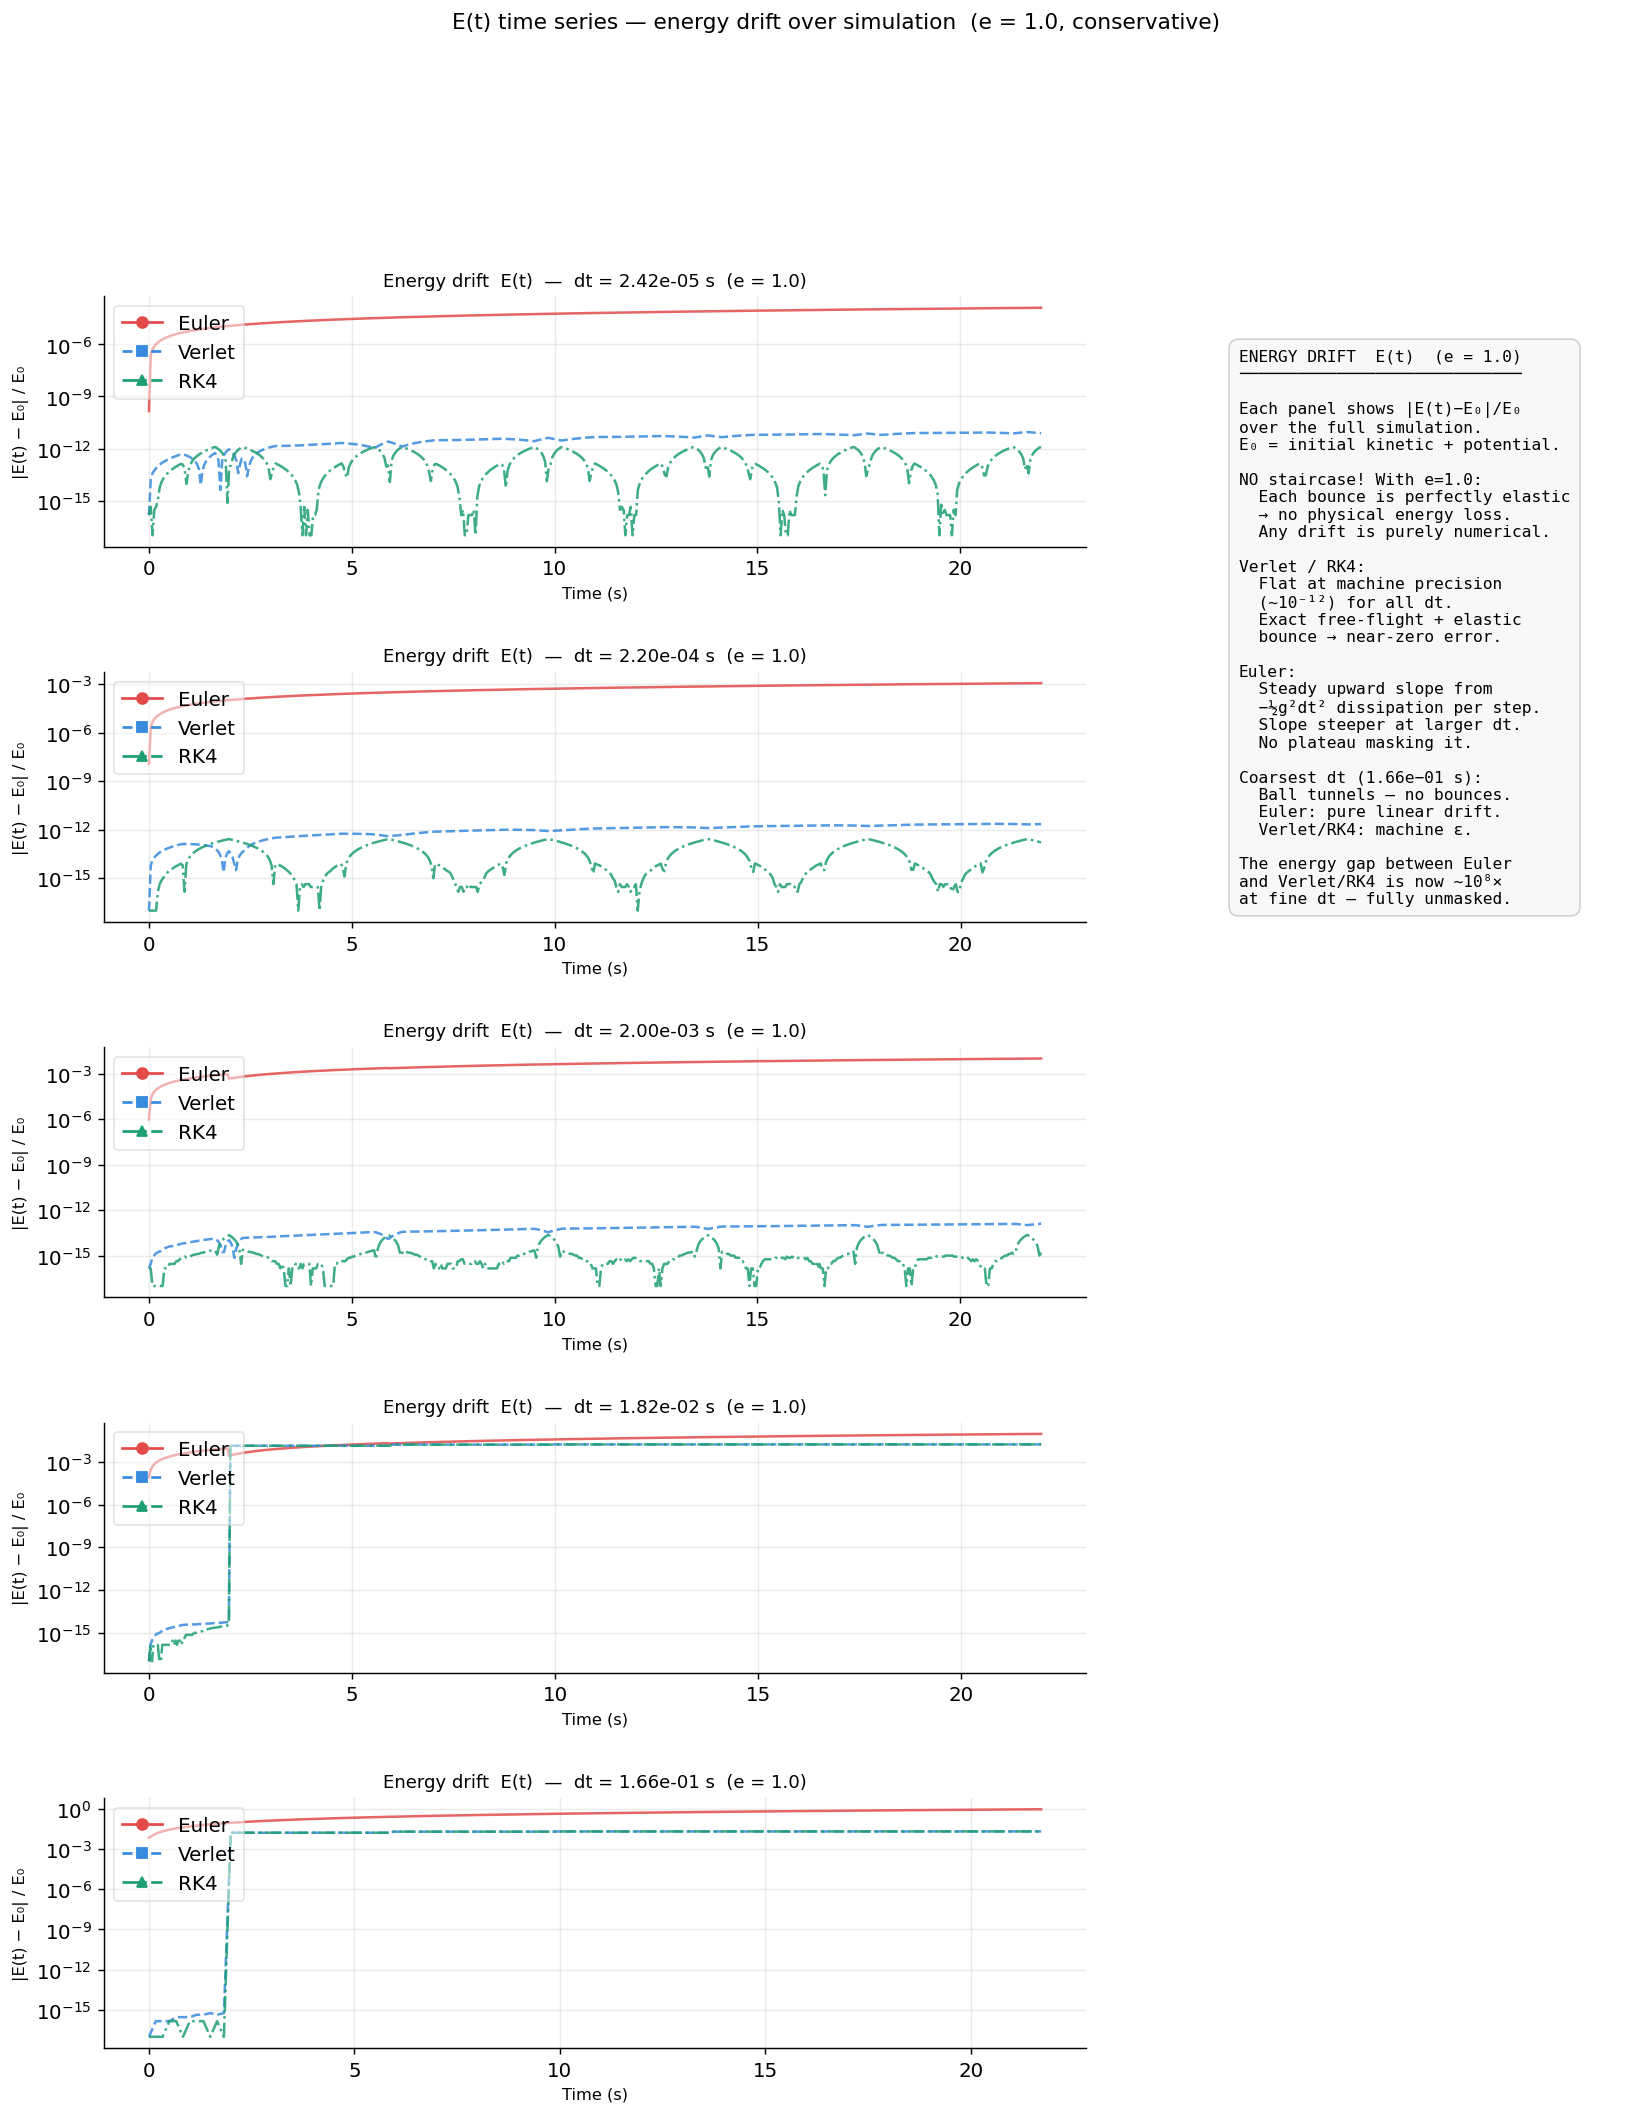

In [9]:
import matplotlib.gridspec as gridspec

selected_dts = sorted(ede['dt'].unique())
n_panels = len(selected_dts)

fig = plt.figure(figsize=(15, 3.5 * n_panels))
gs = gridspec.GridSpec(n_panels, 2, width_ratios=[2.5, 1], hspace=0.5)

for i, dt_val in enumerate(selected_dts):
    ax = fig.add_subplot(gs[i, 0])
    for solver in ['Euler', 'Verlet', 'RK4']:
        sub = ede[(ede['solver'] == solver) & np.isclose(ede['dt'], dt_val)].sort_values('time')
        s = SOLVER_STYLE[solver]
        ax.semilogy(sub['time'], sub['energy_drift'].clip(lower=1e-17),
                    color=s['color'], ls=s['ls'], lw=1.4, label=solver, alpha=0.85)
    ax.set_title(f'Energy drift  E(t)  —  dt = {dt_val:.2e} s  (e = 1.0)', fontsize=10)
    ax.set_ylabel('|E(t) − E₀| / E₀', fontsize=9)
    ax.set_xlabel('Time (s)', fontsize=9)
    solver_legend(ax, loc='upper left')

ax_notes = fig.add_subplot(gs[:, 1])
ax_notes.axis('off')
notes = (
    'ENERGY DRIFT  E(t)  (e = 1.0)\n'
    '─────────────────────────────\n\n'
    'Each panel shows |E(t)−E₀|/E₀\n'
    'over the full simulation.\n'
    'E₀ = initial kinetic + potential.\n\n'
    'NO staircase! With e=1.0:\n'
    '  Each bounce is perfectly elastic\n'
    '  → no physical energy loss.\n'
    '  Any drift is purely numerical.\n\n'
    'Verlet / RK4:\n'
    '  Flat at machine precision\n'
    '  (~10⁻¹²) for all dt.\n'
    '  Exact free-flight + elastic\n'
    '  bounce → near-zero error.\n\n'
    'Euler:\n'
    '  Steady upward slope from\n'
    '  −½g²dt² dissipation per step.\n'
    '  Slope steeper at larger dt.\n'
    '  No plateau masking it.\n\n'
    'Coarsest dt (1.66e−01 s):\n'
    '  Ball tunnels — no bounces.\n'
    '  Euler: pure linear drift.\n'
    '  Verlet/RK4: machine ε.\n\n'
    'The energy gap between Euler\n'
    'and Verlet/RK4 is now ~10⁸×\n'
    'at fine dt — fully unmasked.'
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
    fontsize=9, va='top', family='monospace',
    bbox=dict(boxstyle='round,pad=0.6', fc='#f8f8f8', ec='#cccccc', lw=0.8))

fig.suptitle('E(t) time series — energy drift over simulation  (e = 1.0, conservative)', fontsize=12, y=1.005)
plt.savefig('plot_energy_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
rows = []
for solver, grp in df.groupby("solver"):
    best_row = grp.loc[grp["dt"].idxmin()]
    worst_row = grp.loc[grp["dt"].idxmax()]

    # Bounce count: accept ±1 tolerance (discrete timing never gives exactly N)
    stable_pct = (abs(grp["bounce_count"] - expected_n) <= 1).mean() * 100

    rows.append(
        {
            "Solver": solver,
            "Best height error": f"{best_row['max_height_error']:.2e}",
            "Flight energy drift (min dt)": f"{best_row['max_flight_energy_drift']:.2e}",
            "Max total energy drift": f"{best_row['max_energy_drift']:.2e}",
            "Bounce count ±1 (%)": f"{stable_pct:.0f}%",
            "CPU @ min dt (ms)": f"{best_row['cpu_ms']:.1f}",
        }
    )

summary = pd.DataFrame(rows).set_index("Solver")
print("Notes:")
print(
    f"  • 'Flight energy drift' = integrator error only (between bounces). Verlet/RK4 are at machine ε."
)
print(
    f"  • 'Max total energy drift' at min dt ≈ 1 − e^(2×7) = {1 - RESTITUTION ** (2 * 7):.3f} (7 bounces × physical loss)"
)
print(
    f"  • 'Bounce count ±1' uses |count − {expected_n}| ≤ 1 (discrete timing offset of ±1 bounce is expected)\n"
)
summary

Notes:
  • 'Flight energy drift' = integrator error only (between bounces). Verlet/RK4 are at machine ε.
  • 'Max total energy drift' at min dt ≈ 1 − e^(2×7) = 0.000 (7 bounces × physical loss)
  • 'Bounce count ±1' uses |count − 6| ≤ 1 (discrete timing offset of ±1 bounce is expected)



,Best height error,Flight energy drift (min dt),Max total energy drift,Bounce count ±1 (%),CPU @ min dt (ms)
Solver,,,,,
Euler,4.83e-05,9.65e-06,5.40e-05,84%,930.6
RK4,2.45e-11,3.40e-12,3.04e-12,90%,3244.9
Verlet,7.18e-11,1.79e-11,8.22e-11,90%,1533.2


## Summary statistics table

In [11]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_flight_energy_drift.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_bounce_count.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        try:
            img = plt.imread(path)
            fig, ax = plt.subplots(figsize=(14, 7))
            ax.imshow(img)
            ax.axis("off")
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)
        except FileNotFoundError:
            print(f"Skipping {path} (not yet generated — run all cells first)")

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf


## Export all plots to PDF

In [12]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_bounce_count.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf
